Supervised Model: Logistic Regression

- Sanity check before Random Forest. If a feature has no linear relationship with returns, coefficient will be near 0
- Uses sigmoid function: P(up) = 1 / (1 + e^(-z)) where z = beta^T * x
- Threshold: P > 0.55 → buy, P < 0.45 → sell, else hold
- Signal shifted by 1 bar to prevent look-ahead bias
- If RF barely beats LogReg, the features matter more than the model

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/Users/giovanafalcao/Desktop/Projects/trading-analytics")
from utils import yfinance_fix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

TICKER = "AAPL"
INTERVAL = "1d"
PERIOD = "max"
LOOKBACK = 10000
TARGET_SHIFT = 1
TRAIN_RATIO = 0.8
THRESHOLD = 0.55

FEATURES = ["momentum_21d", "momentum_252_21d", "vol_ratio", "hv_20", "illiquidity", "autocorr_20",
            "RSI", "MACD_HIST", "ATR", "BB_Percent", "MFI"]

# Fetch data
df = yf.download(TICKER, session=yfinance_fix.chrome_session, interval=INTERVAL, period=PERIOD)
df.columns = df.columns.get_level_values(0)
df = df.iloc[-LOOKBACK:, :]

# Compute features (same as sl_x_y.ipynb)
log_returns = np.log(df["Close"] / df["Close"].shift(1))
df["momentum_21d"] = df["Close"].pct_change(21)
df["momentum_252_21d"] = df["Close"].pct_change(252) - df["Close"].pct_change(21)
df["vol_ratio"] = log_returns.rolling(5).std() / log_returns.rolling(20).std()
df["hv_20"] = log_returns.rolling(20).std() * np.sqrt(252)
df["illiquidity"] = (log_returns.abs() / df["Volume"]).rolling(20).mean()
df["autocorr_20"] = log_returns.rolling(20).apply(lambda x: x.autocorr(lag=1))

price_change = df["Close"].diff()
gain = price_change.where(price_change > 0, 0)
loss = -price_change.where(price_change < 0, 0)
df["RSI"] = 100 - (100 / (1 + gain.rolling(14).mean() / loss.rolling(14).mean()))
ema_fast = df["Close"].ewm(span=12).mean()
ema_slow = df["Close"].ewm(span=26).mean()
macd_line = ema_fast - ema_slow
df["MACD_HIST"] = macd_line - macd_line.ewm(span=9).mean()
high_low = df["High"] - df["Low"]
high_close = (df["High"] - df["Close"].shift(1)).abs()
low_close = (df["Low"] - df["Close"].shift(1)).abs()
df["ATR"] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1).rolling(14).mean()
sma = df["Close"].rolling(20).mean()
rolling_std = df["Close"].rolling(20).std()
df["BB_Percent"] = (df["Close"] - (sma - 2 * rolling_std)) / (4 * rolling_std)
typical = (df["High"] + df["Low"] + df["Close"]) / 3
mf = typical * df["Volume"]
delta = typical.diff()
df["MFI"] = 100 - (100 / (1 + mf.where(delta > 0, 0).rolling(14).sum() / mf.where(delta < 0, 0).rolling(14).sum()))

# Target + clean
df["Target"] = (df["Close"].shift(-TARGET_SHIFT) > df["Close"]).astype(int)
df = df.iloc[:-TARGET_SHIFT]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES + ["Target"])

# Temporal split + scale
split_idx = int(len(df) * TRAIN_RATIO)
train = df.iloc[:split_idx - TARGET_SHIFT]
test = df.iloc[split_idx:]
X_train, y_train = train[FEATURES], train["Target"]
X_test, y_test = test[FEATURES], test["Target"]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

[yfinance_fix] Patch erfolgreich angewendet.
[yfinance_fix] Chrome-Session erstellt.
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Train: 7796 rows | Test: 1950 rows


In [2]:
# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

# Predict probabilities on test set
proba = model.predict_proba(X_test_s)[:, 1]

# Threshold-based signals: buy / hold / sell
signals = np.where(proba > THRESHOLD, 1, np.where(proba < (1 - THRESHOLD), -1, 0))

# Binary predictions for metrics (standard classification threshold 0.5)
predictions = (proba > 0.5).astype(int)

print("ML Metrics (test set):")
print(f"  Accuracy:  {accuracy_score(y_test, predictions):.4f}")
print(f"  Precision: {precision_score(y_test, predictions, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, predictions, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, predictions, zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, proba):.4f}")

print(f"\nSignal distribution (threshold={THRESHOLD}):")
print(f"  Buy:  {(signals == 1).sum()}")
print(f"  Hold: {(signals == 0).sum()}")
print(f"  Sell: {(signals == -1).sum()}")

ML Metrics (test set):
  Accuracy:  0.4897
  Precision: 0.5363
  Recall:    0.3740
  F1:        0.4407
  ROC-AUC:   0.5003

Signal distribution (threshold=0.55):
  Buy:  329
  Hold: 869
  Sell: 752


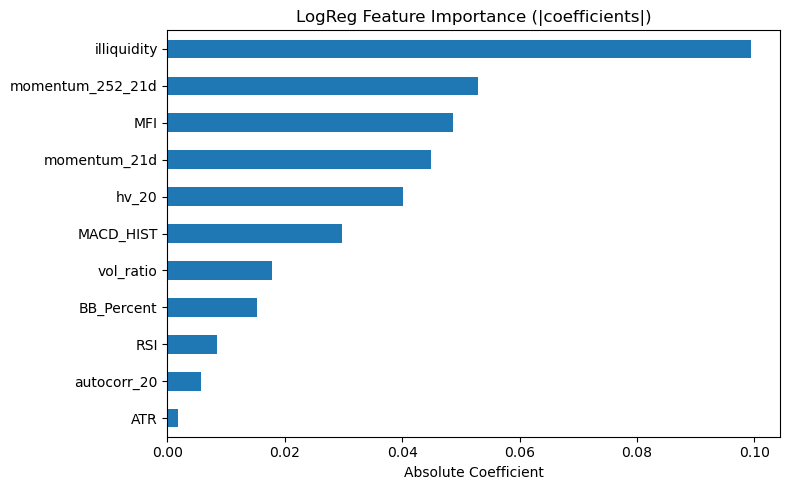


Coefficients (with sign):
          momentum_21d: -0.0449
      momentum_252_21d: +0.0528
             vol_ratio: +0.0177
                 hv_20: -0.0402
           illiquidity: -0.0994
           autocorr_20: -0.0058
                   RSI: -0.0084
             MACD_HIST: +0.0297
                   ATR: +0.0018
            BB_Percent: -0.0153
                   MFI: +0.0487


In [3]:
# Feature coefficients — which features matter most?
# Larger |coefficient| = more influence on the prediction
coefs = pd.Series(np.abs(model.coef_[0]), index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
coefs.plot(kind="barh")
plt.title("LogReg Feature Importance (|coefficients|)")
plt.xlabel("Absolute Coefficient")
plt.tight_layout()
plt.show()

print("\nCoefficients (with sign):")
for f, c in zip(FEATURES, model.coef_[0]):
    print(f"  {f:>20s}: {c:+.4f}")

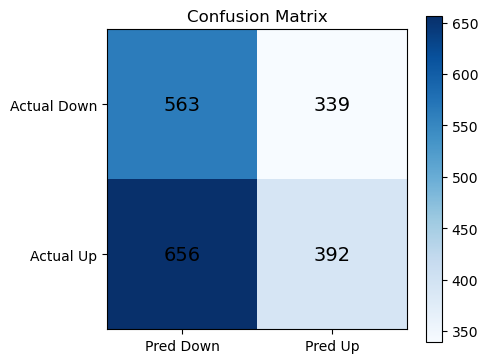

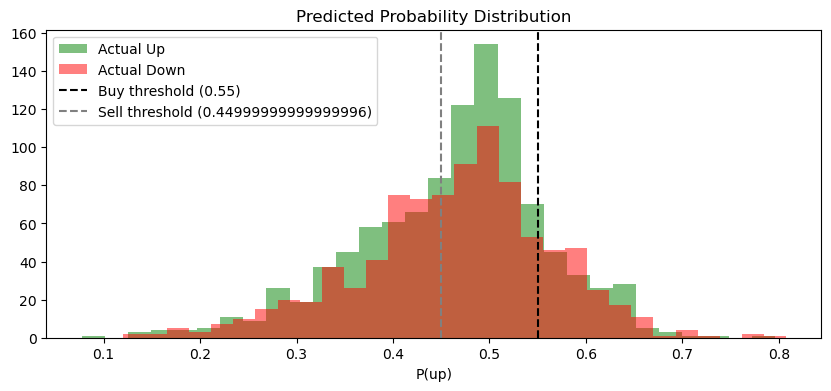

In [4]:
# Confusion matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)
plt.xticks([0, 1], ["Pred Down", "Pred Up"])
plt.yticks([0, 1], ["Actual Down", "Actual Up"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Probability distribution
plt.figure(figsize=(10, 4))
plt.hist(proba[y_test == 1], bins=30, alpha=0.5, label="Actual Up", color="green")
plt.hist(proba[y_test == 0], bins=30, alpha=0.5, label="Actual Down", color="red")
plt.axvline(THRESHOLD, color="black", linestyle="--", label=f"Buy threshold ({THRESHOLD})")
plt.axvline(1 - THRESHOLD, color="gray", linestyle="--", label=f"Sell threshold ({1-THRESHOLD})")
plt.title("Predicted Probability Distribution")
plt.xlabel("P(up)")
plt.legend()
plt.show()

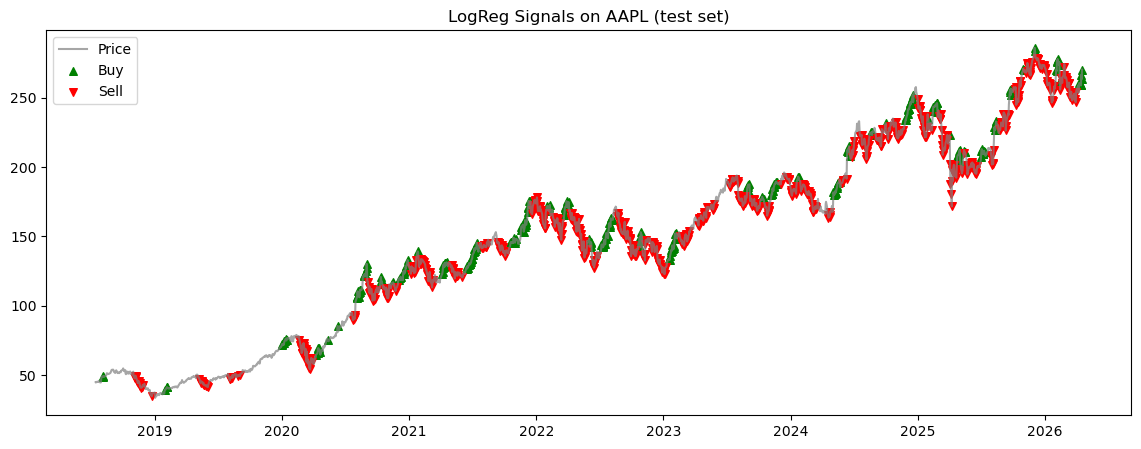

In [5]:
# Signal chart — buy/sell markers on price
test_df = test.copy()
test_df["signal"] = signals

plt.figure(figsize=(14, 5))
plt.plot(test_df.index, test_df["Close"], color="gray", alpha=0.7, label="Price")
buy_mask = test_df["signal"] == 1
sell_mask = test_df["signal"] == -1
plt.scatter(test_df.index[buy_mask], test_df["Close"][buy_mask], marker="^", color="green", s=30, label="Buy")
plt.scatter(test_df.index[sell_mask], test_df["Close"][sell_mask], marker="v", color="red", s=30, label="Sell")
plt.title(f"LogReg Signals on {TICKER} (test set)")
plt.legend()
plt.show()